##Setup & Data Ingestion
First, we install the necessary library yfinance to fetch market data. Then we define a diversified list of tickers to ensure our dataset is "rich" enough for analysis.

In [4]:
# Cell 1: Install Library
# Run this once when you start the notebook
!pip install yfinance

In [5]:

# Import libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Settings for plots
plt.style.use('seaborn-v0_8')
sns.set(font_scale=1.2)

In [7]:
# Cell 2: Download Data (下載數據) - 修正版 (Fixed Version)

# 1. Define Tickers (定義股票代碼)
tickers = [
    'AAPL', 'MSFT', 'NVDA', 'AMD',   # Tech (科技)
    'JPM', 'BAC', 'GS', 'MS',        # Finance (金融)
    'XOM', 'CVX',                    # Energy (能源)
    'JNJ', 'PFE',                    # Healthcare (醫療)
    'KO', 'PEP', 'MCD'               # Consumer Defensive (消費)
]

# 2. Set Timeframe (設定時間範圍)
start_date = '2019-01-01'
end_date = '2024-12-31'

# 3. Download Data (下載數據)
print("Downloading data... (正在下載數據...)")

# 修改點：加入 auto_adjust=False，這樣才能獲取 'Adj Close' 欄位
# Modification: Added auto_adjust=False to ensure 'Adj Close' column is returned
df_prices = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)['Adj Close']

# 4. Data Inspection (數據檢查)
print(f"Data Shape (數據維度): {df_prices.shape}")
df_prices.head()

[******                13%                       ]  2 of 15 completed

[*********************100%***********************]  15 of 15 completed


Data Shape (數據維度): (1509, 15)


Ticker,AAPL,AMD,BAC,CVX,GS,JNJ,JPM,KO,MCD,MS,MSFT,NVDA,PEP,PFE,XOM
Date,,,,,,,,,,,,,,,
2019-01-02,37.538826,18.830000,21.063486,81.392754,146.156815,104.942810,81.616692,37.841114,149.628967,32.492104,94.612617,3.377167,88.388458,29.785070,50.335129
2019-01-03,33.799675,17.049999,20.725933,79.833862,144.015793,103.275238,80.456795,37.607269,148.643097,31.913031,91.131989,3.173128,87.563461,28.951771,49.562290
2019-01-04,35.242554,19.000000,21.586700,81.488350,148.722656,105.008537,83.422874,38.357162,151.515701,33.215942,95.370483,3.376422,89.359039,29.612898,51.389637
2019-01-07,35.164112,20.570000,21.569820,82.547203,149.546677,104.334953,83.480865,37.857235,153.164474,33.545689,95.492119,3.555173,88.590652,29.771294,51.656876
2019-01-08,35.834450,20.750000,21.527628,82.186897,148.994476,106.758270,83.323433,38.284592,153.487411,33.336582,96.184502,3.466666,89.439957,29.909027,52.032444


##Preprocessing - Log Returns
We convert prices to Log Returns. Prices are non-stationary (statistical properties change over time), while returns are stationary, which is a requirement for PCA and correlation analysis.

$$r_t = \ln\left( \frac{P_t}{P_{t-1}} \right)$$



/tmp/ipython-input-3130206934.py:22: UserWarning: Glyph 34315 (\N{CJK UNIFIED IDEOGRAPH-860B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3130206934.py:22: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3130206934.py:22: UserWarning: Glyph 32929 (\N{CJK UNIFIED IDEOGRAPH-80A1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3130206934.py:22: UserWarning: Glyph 20729 (\N{CJK UNIFIED IDEOGRAPH-50F9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3130206934.py:22: UserWarning: Glyph 38750 (\N{CJK UNIFIED IDEOGRAPH-975E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3130206934.py:22: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3130206934.py:22: UserWarning: Glyph 31337 (\N{CJK UNIFIED IDEOGRAPH-7A69}) missi

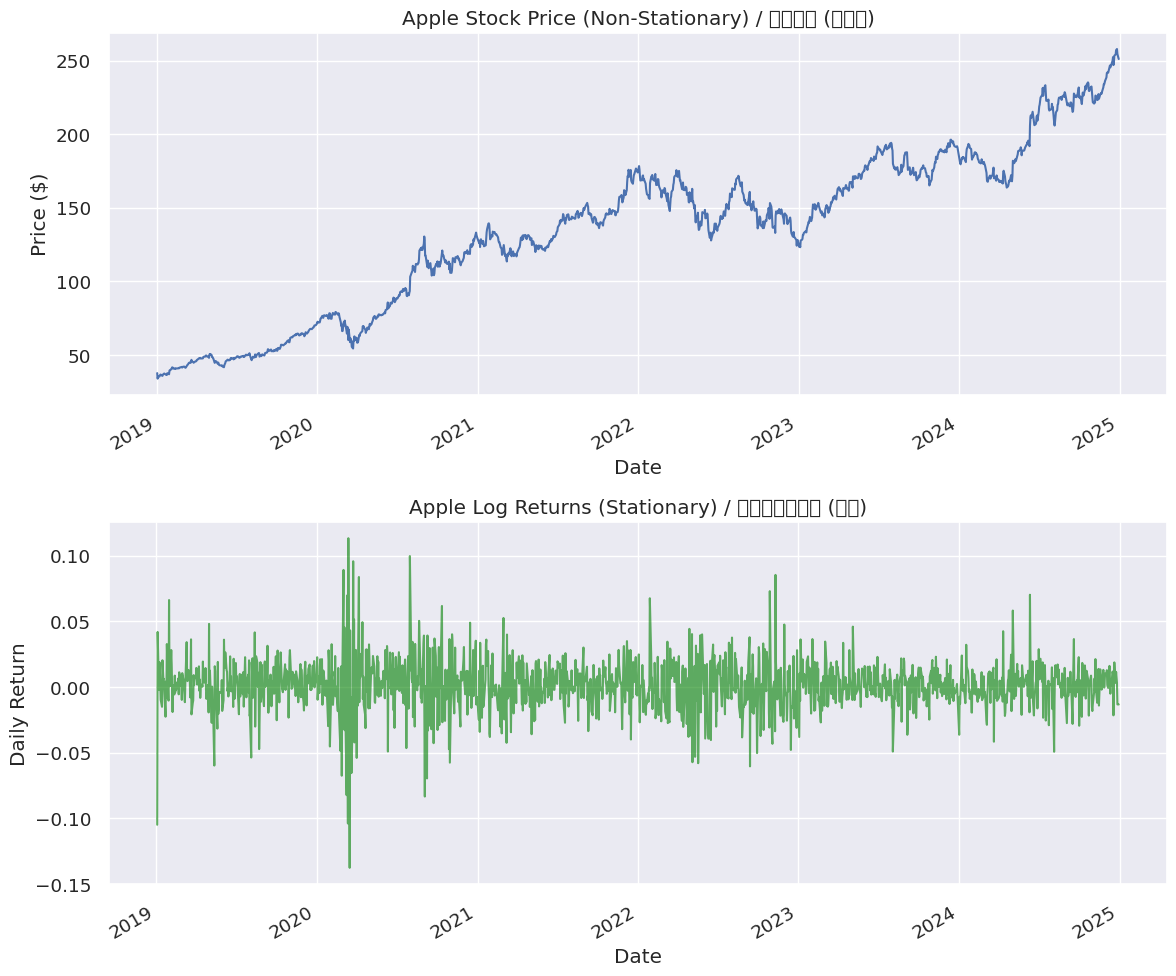

In [8]:
# Cell 3: Calculate Log Returns (計算對數收益率)

# Calculate Log Returns
# 計算公式：ln(P_t / P_{t-1})
df_returns = np.log(df_prices / df_prices.shift(1))

# Drop NaN values created by the shift operation
# 刪除因位移操作產生的缺失值 (NaN)
df_returns = df_returns.dropna()

# Visualizing the difference (視覺化差異)
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Raw Prices
df_prices['AAPL'].plot(ax=ax[0], title='Apple Stock Price (Non-Stationary) / 蘋果股價 (非平穩)')
ax[0].set_ylabel('Price ($)')

# Plot 2: Log Returns
df_returns['AAPL'].plot(ax=ax[1], title='Apple Log Returns (Stationary) / 蘋果對數收益率 (平穩)', color='green', alpha=0.6)
ax[1].set_ylabel('Daily Return')

plt.tight_layout()
plt.savefig('price_vs_returns.png', dpi=300) # Save for report
plt.show()

##Principal Component Analysis (PCA) - Market Factor Extraction

We use PCA to extract the main factors driving stock returns. PC1 (First Principal Component) typically represents the "Market Factor" (overall market movement).

/tmp/ipython-input-4185727202.py:33: UserWarning: Glyph 30862 (\N{CJK UNIFIED IDEOGRAPH-788E}) missing from font(s) DejaVu Sans.
  plt.savefig('pca_analysis.png', dpi=300)
/tmp/ipython-input-4185727202.py:33: UserWarning: Glyph 30707 (\N{CJK UNIFIED IDEOGRAPH-77F3}) missing from font(s) DejaVu Sans.
  plt.savefig('pca_analysis.png', dpi=300)
/tmp/ipython-input-4185727202.py:33: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  plt.savefig('pca_analysis.png', dpi=300)
/tmp/ipython-input-4185727202.py:33: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.savefig('pca_analysis.png', dpi=300)
/tmp/ipython-input-4185727202.py:33: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) DejaVu Sans.
  plt.savefig('pca_analysis.png', dpi=300)
/tmp/ipython-input-4185727202.py:33: UserWarning: Glyph 22580 (\N{CJK UNIFIED IDEOGRAPH-5834}) missing from font(s) DejaVu Sans.
  plt.savefig('pca_ana

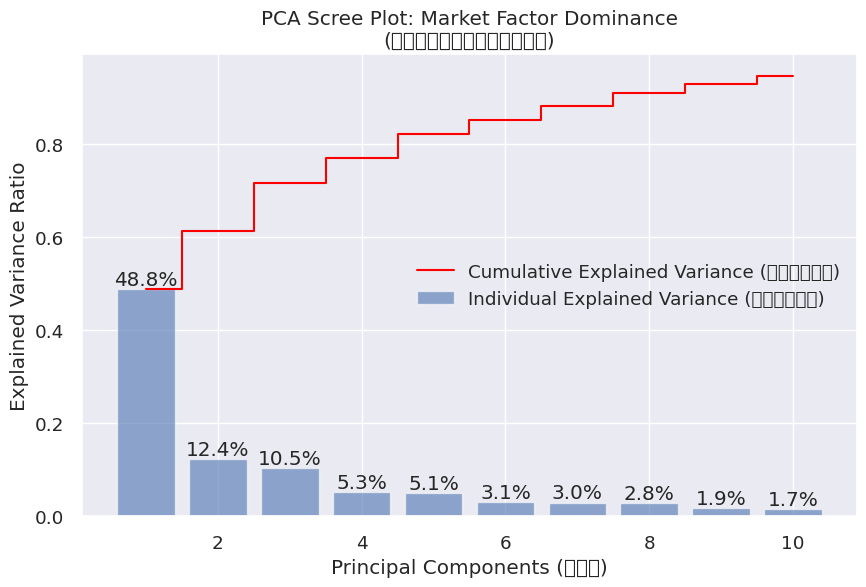

PC1 explains 48.84% of the total variance.
PC1 解釋了 48.84% 的總變異量。


In [9]:
# Cell 4: PCA Analysis (主成分分析)

# 1. Standardization (標準化)
# PCA requires data to have zero mean and unit variance.
# PCA 要求數據具有零均值和單位變異數。
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_returns)

# 2. Fit PCA (擬合 PCA)
pca = PCA(n_components=10)
pca.fit(df_scaled)

# 3. Explained Variance (解釋變異量)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# 4. Scree Plot (碎石圖)
plt.figure(figsize=(10, 6))
bars = plt.bar(range(1, 11), explained_variance, alpha=0.6, label='Individual Explained Variance (個別解釋變異)')
plt.step(range(1, 11), cumulative_variance, where='mid', color='red', label='Cumulative Explained Variance (累積解釋變異)')

plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components (主成分)')
plt.title('PCA Scree Plot: Market Factor Dominance\n(碎石圖：市場因子的主導地位)')
plt.legend(loc='best')
plt.grid(True)

# Add percentage labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval*100:.1f}%', ha='center', va='bottom')

plt.savefig('pca_analysis.png', dpi=300)
plt.show()

print(f"PC1 explains {explained_variance[0]*100:.2f}% of the total variance.")
print(f"PC1 解釋了 {explained_variance[0]*100:.2f}% 的總變異量。")

##Clustering analysis - finding correlation structures
We transpose the matrix to cluster stocks based on their correlation, rather than clustering days. We use K-Means to group similar assets


   Ticker  Cluster      Sector
7      MS        0     Finance
5     BAC        0     Finance
12     KO        0    Consumer
8     XOM        0      Energy
13    PEP        0    Consumer
6      GS        1     Finance
2    NVDA        1        Tech
4     JPM        1     Finance
9     CVX        1      Energy
11    PFE        2  Healthcare
0    AAPL        2        Tech
1    MSFT        2        Tech
10    JNJ        2  Healthcare
3     AMD        3        Tech
14    MCD        3    Consumer


/tmp/ipython-input-3007458799.py:39: UserWarning: Glyph 32929 (\N{CJK UNIFIED IDEOGRAPH-80A1}) missing from font(s) DejaVu Sans.
  plt.savefig('clustermap.png', dpi=300)
/tmp/ipython-input-3007458799.py:39: UserWarning: Glyph 31080 (\N{CJK UNIFIED IDEOGRAPH-7968}) missing from font(s) DejaVu Sans.
  plt.savefig('clustermap.png', dpi=300)
/tmp/ipython-input-3007458799.py:39: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  plt.savefig('clustermap.png', dpi=300)
/tmp/ipython-input-3007458799.py:39: UserWarning: Glyph 38364 (\N{CJK UNIFIED IDEOGRAPH-95DC}) missing from font(s) DejaVu Sans.
  plt.savefig('clustermap.png', dpi=300)
/tmp/ipython-input-3007458799.py:39: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.savefig('clustermap.png', dpi=300)
/tmp/ipython-input-3007458799.py:39: UserWarning: Glyph 33287 (\N{CJK UNIFIED IDEOGRAPH-8207}) missing from font(s) DejaVu Sans.
  plt.savefig('cluste

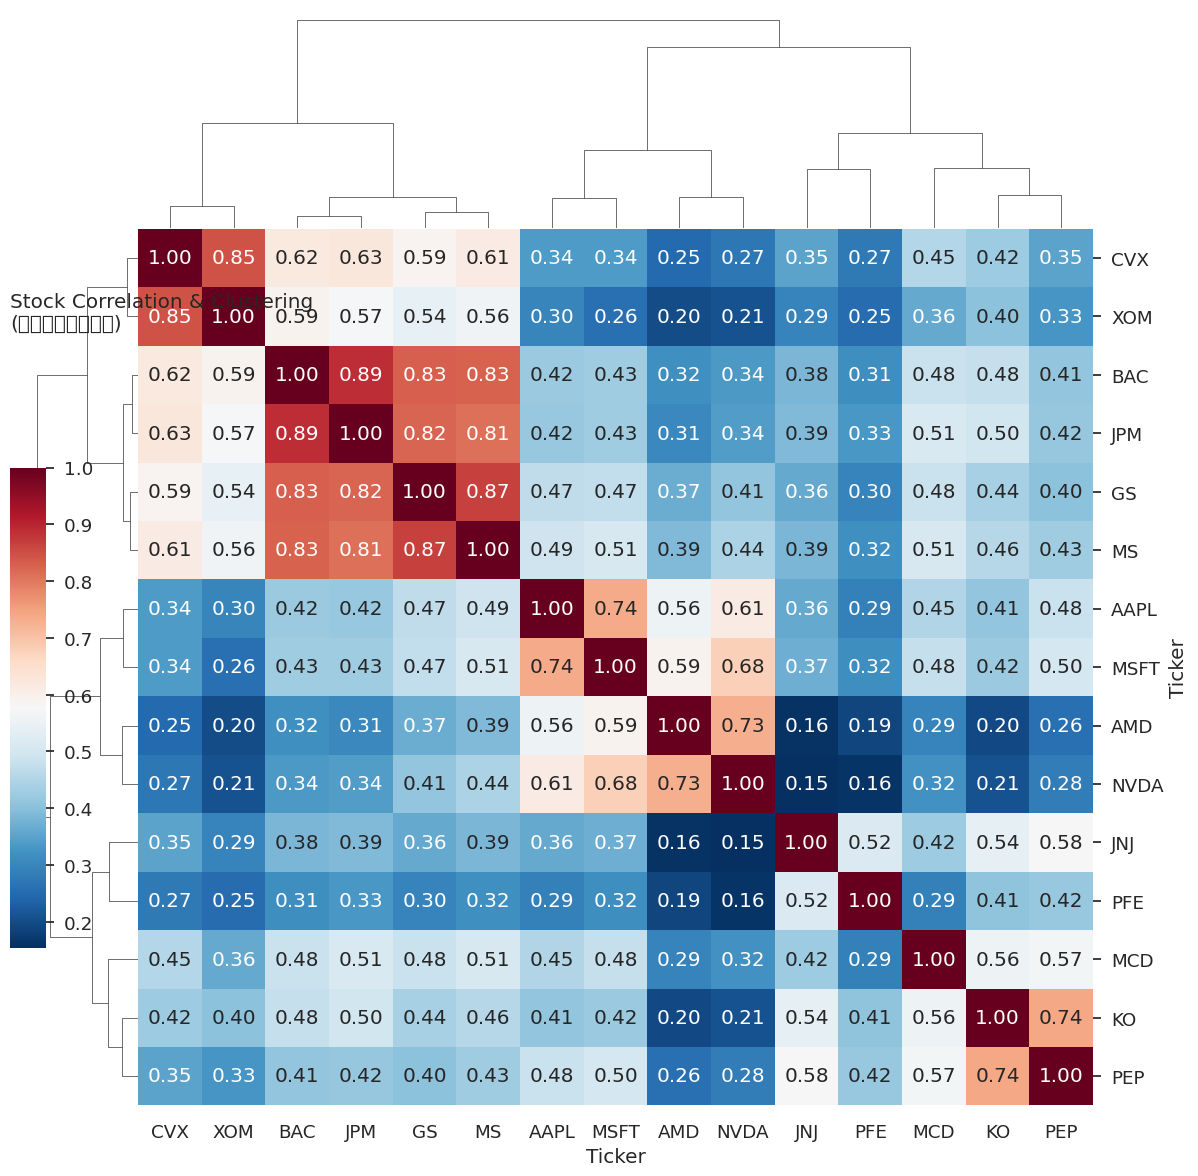

In [10]:
# Cell 5: Clustering (分群分析)

# 1. Calculate Correlation Matrix (計算相關係數矩陣)
# This represents the "distance" or similarity between stocks.
# 這代表了股票之間的「距離」或相似度。
correlation_matrix = df_returns.corr()

# 2. K-Means Clustering (K-Means 分群)
# Let's try to find 4 clusters.
# 我們嘗試找出 4 個群集。
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(correlation_matrix)
labels = kmeans.labels_

# 3. Create a DataFrame for results (建立結果 DataFrame)
cluster_results = pd.DataFrame({
    'Ticker': tickers,
    'Cluster': labels,
    'Sector': ['Tech']*4 + ['Finance']*4 + ['Energy']*2 + ['Healthcare']*2 + ['Consumer']*3 # Manual labels for comparison
})

# Sort by Cluster to see the grouping
print(cluster_results.sort_values(by='Cluster'))

# 4. Visualization: Clustermap (視覺化：熱圖與樹狀圖)
# This plots the correlation matrix and reorders it based on similarity.
# 這會繪製相關係數熱圖，並根據相似度重新排序。
g = sns.clustermap(correlation_matrix,
                   method='ward',
                   cmap='RdBu_r', # Red-Blue colormap
                   annot=True,    # Show numbers
                   fmt='.2f',     # 2 decimal places
                   figsize=(12, 12),
                   dendrogram_ratio=(.1, .2),
                   cbar_pos=(0, .2, .03, .4))

plt.title('Stock Correlation & Clustering\n(股票相關性與分群)', loc='left', pad=100)
plt.savefig('clustermap.png', dpi=300)
plt.show()

##Interpreting PC1 Loadings
We extract the weights (loadings) of the first principal component (PC1). These weights show which stocks contribute the most to the overall "Market Factor." High positive weights indicate stocks that are strongly influenced by the market's common movement.

--- Stocks Most Defining the Market Factor (最能定義市場因子的股票) ---
        PC1 Loading (Absolute)
Ticker                        
MS                    0.314211
JPM                   0.306873
GS                    0.306188
BAC                   0.306101
CVX                   0.265422
MSFT                  0.262255
AAPL                  0.255806
MCD                   0.255129
KO                    0.253332
PEP                   0.250427
XOM                   0.243028
JNJ                   0.216847
NVDA                  0.212157
AMD                   0.198115
PFE                   0.180723


/tmp/ipython-input-277647775.py:24: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-277647775.py:24: UserWarning: Glyph 25903 (\N{CJK UNIFIED IDEOGRAPH-652F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-277647775.py:24: UserWarning: Glyph 32929 (\N{CJK UNIFIED IDEOGRAPH-80A1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-277647775.py:24: UserWarning: Glyph 31080 (\N{CJK UNIFIED IDEOGRAPH-7968}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-277647775.py:24: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-277647775.py:24: UserWarning: Glyph 27402 (\N{CJK UNIFIED IDEOGRAPH-6B0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-277647775.py:24: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from

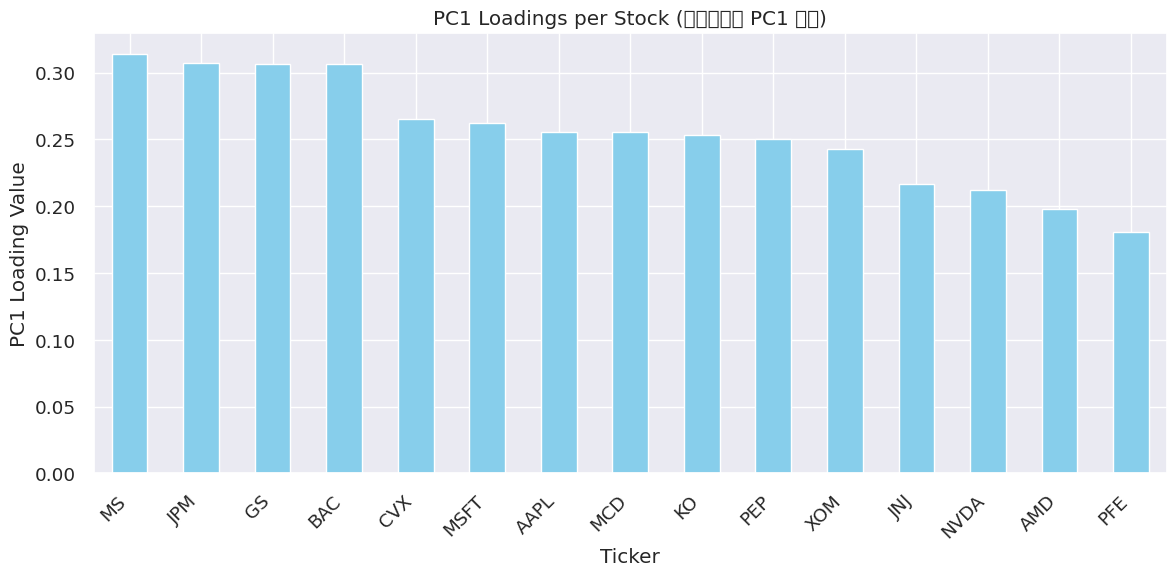

In [11]:
# Cell 6: PC1 Loadings Analysis (PC1 權重分析)

# 1. Extract PC1 Loadings (提取 PC1 權重)
# PC1 is the first row (index 0) of the components matrix.
# PC1 是 components 矩陣的第一行 (索引 0)。
pc1_loadings = pd.Series(pca.components_[0], index=df_returns.columns)

# 2. Sort the Loadings (排序權重)
# Sort by absolute value to see the stocks with the strongest influence, regardless of direction.
# 按絕對值排序，以查看影響力最強的股票，不論方向。
pc1_loadings_sorted = pc1_loadings.abs().sort_values(ascending=False)
pc1_loadings_df = pd.DataFrame(pc1_loadings_sorted, columns=['PC1 Loading (Absolute)'])

print("--- Stocks Most Defining the Market Factor (最能定義市場因子的股票) ---")
print(pc1_loadings_df)

# 3. Visualization: Bar Plot (視覺化：長條圖)
plt.figure(figsize=(12, 6))
pc1_loadings.sort_values(ascending=False).plot(kind='bar', color=np.where(pc1_loadings.sort_values(ascending=False) > 0, 'skyblue', 'salmon'))
plt.title('PC1 Loadings per Stock (每支股票的 PC1 權重)')
plt.ylabel('PC1 Loading Value')
plt.xlabel('Ticker')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('pc1_loadings.png', dpi=300)
plt.show()

# Financial Context:
# If high-beta stocks (like NVDA or AMD) have the highest positive loadings, it confirms PC1 is indeed the market factor.
# 金融意涵：如果高貝塔值股票（如 NVDA 或 AMD）具有最高的正權重，則確認 PC1 確實是市場因子。

##Validating Cluster Performance
To validate the K-Means result, we calculate the average daily return for each cluster and plot them over time. If the stocks are grouped correctly, the mean return of a cluster should demonstrate a cohesive movement.

/tmp/ipython-input-1629926879.py:44: UserWarning: Glyph 32929 (\N{CJK UNIFIED IDEOGRAPH-80A1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1629926879.py:44: UserWarning: Glyph 31080 (\N{CJK UNIFIED IDEOGRAPH-7968}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1629926879.py:44: UserWarning: Glyph 32676 (\N{CJK UNIFIED IDEOGRAPH-7FA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1629926879.py:44: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1629926879.py:44: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1629926879.py:44: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1629926879.py:44: UserWarning: Glyph 31309 (\N{CJK UNIFIED IDEOGRAPH-7A4D}) missi

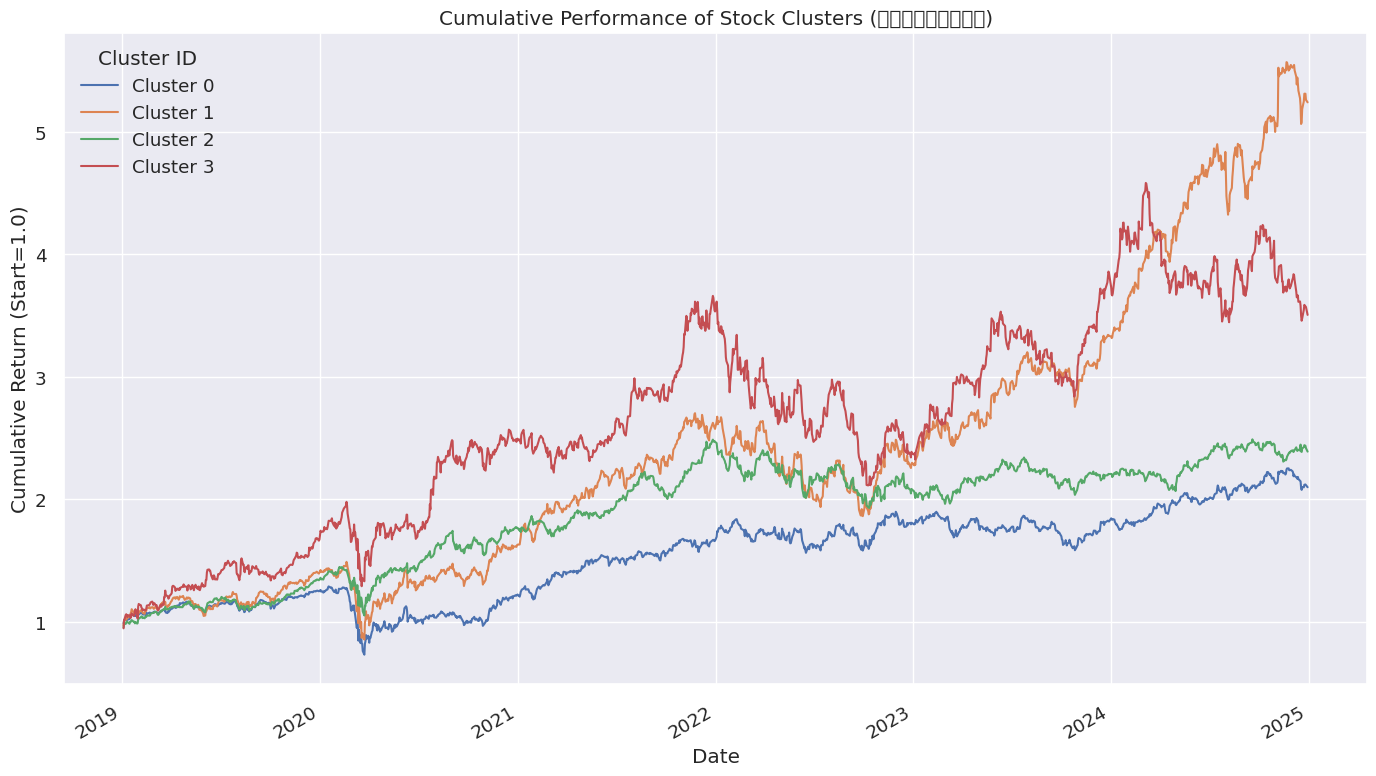

Visualization Complete. Interpret the graph to see which cluster performed best.


In [13]:
# Cell 7: Cluster Performance Visualization (群集績效視覺化) - FIXED

# 1. Prepare Data (準備數據)
# We need to map the cluster labels to the returns data.
# 我們需要將群集標籤對應到收益率數據。

# Create a mapping series: Ticker -> Cluster
cluster_map = cluster_results.set_index('Ticker')['Cluster']

# Transpose df_returns so Tickers are the Index (Rows) and Dates are Columns
# 將 df_returns 轉置，讓股票代碼變為索引（列），日期變為欄位
df_transposed = df_returns.T

# Join the Cluster information
# 加入群集資訊
df_transposed['Cluster'] = cluster_map

# 2. Calculate Mean Return for Each Cluster (計算每個群集的平均收益率)
# Group by 'Cluster' and take the mean. Since dates are columns, this calculates the daily mean for the cluster.
# 按 'Cluster' 分組並取平均值。由於日期是欄位，這會計算該群集的每日平均值。
cluster_means = df_transposed.groupby('Cluster').mean()

# Transpose back so we have Dates as Index again for plotting
# 再次轉置回來，讓日期變回索引以便繪圖
cluster_returns_mean = cluster_means.T

# Rename columns for better legend (e.g., "Cluster 0", "Cluster 1")
cluster_returns_mean.columns = [f'Cluster {i}' for i in cluster_returns_mean.columns]

# 3. Plot Cumulative Performance (繪製累積績效)
plt.figure(figsize=(14, 8))

# Calculate Cumulative Returns: (1 + r).cumprod()
# 計算累積收益：使用 cumsum 對數收益率轉換回價格趨勢
cumulative_returns = cluster_returns_mean.cumsum().apply(np.exp)

cumulative_returns.plot(ax=plt.gca())

plt.title('Cumulative Performance of Stock Clusters (股票群集的累積績效)')
plt.ylabel('Cumulative Return (Start=1.0)')
plt.xlabel('Date')
plt.legend(title='Cluster ID')
plt.grid(True)
plt.tight_layout()

# Save the plot
plt.savefig('cluster_performance.png', dpi=300)
plt.show()

print("Visualization Complete. Interpret the graph to see which cluster performed best.")